In [1]:
import torch
from torch import nn
import os
import pandas as pd
from torchvision import transforms
from torch.utils.data import Dataset
from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import StratifiedGroupKFold
import random
from sklearn.model_selection import GroupShuffleSplit

In [2]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
set_seed(42)

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# import tarfile

# tar_path = "/content/drive/MyDrive/BreaKHis_v1.tar.gz"
# extract_path = "/content/dataset"

# with tarfile.open(tar_path, "r:gz") as tar:
#     tar.extractall(path=extract_path)

# print("Done!")

In [5]:

root = "/kaggle/input/datasets/ambarish/breakhis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"

data = []

for label in ["benign", "malignant"]:

    label_path = os.path.join(root, label, "SOB")

    for subtype in os.listdir(label_path):

        subtype_path = os.path.join(label_path, subtype)

        if not os.path.isdir(subtype_path):
            continue

        for patient in os.listdir(subtype_path):

            patient_path = os.path.join(subtype_path, patient)

            if not os.path.isdir(patient_path):
                continue

            for magnification in os.listdir(patient_path):

                mag_path = os.path.join(patient_path, magnification)

                if not os.path.isdir(mag_path):
                    continue

                for image in os.listdir(mag_path):

                    if image.endswith(".png"):
                        data.append({
                            "image_path": os.path.join(mag_path, image),
                            "label": label,
                            "subtype": subtype,
                            "patient_id": patient,
                            "magnification": magnification
                        })

df = pd.DataFrame(data)

print(df.head())
print()
print("Total images:", len(df))

                                          image_path   label   subtype  \
0  /kaggle/input/datasets/ambarish/breakhis/BreaK...  benign  adenosis   
1  /kaggle/input/datasets/ambarish/breakhis/BreaK...  benign  adenosis   
2  /kaggle/input/datasets/ambarish/breakhis/BreaK...  benign  adenosis   
3  /kaggle/input/datasets/ambarish/breakhis/BreaK...  benign  adenosis   
4  /kaggle/input/datasets/ambarish/breakhis/BreaK...  benign  adenosis   

           patient_id magnification  
0  SOB_B_A_14-29960CD          200X  
1  SOB_B_A_14-29960CD          200X  
2  SOB_B_A_14-29960CD          200X  
3  SOB_B_A_14-29960CD          200X  
4  SOB_B_A_14-29960CD          200X  

Total images: 7909


In [6]:
print(df["label"].value_counts())

print(df["magnification"].value_counts())

print(df["subtype"].value_counts())

print("Unique patients:", df["patient_id"].nunique())

label
malignant    5429
benign       2480
Name: count, dtype: int64
magnification
100X    2081
200X    2013
40X     1995
400X    1820
Name: count, dtype: int64
subtype
ductal_carcinoma       3451
fibroadenoma           1014
mucinous_carcinoma      792
lobular_carcinoma       626
tubular_adenoma         569
papillary_carcinoma     560
phyllodes_tumor         453
adenosis                444
Name: count, dtype: int64
Unique patients: 82


In [7]:
df["label"] = df["label"].map({
    "benign": 0,
    "malignant": 1
})

df.head()

,image_path,label,subtype,patient_id,magnification
0,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,adenosis,SOB_B_A_14-29960CD,200X
1,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,adenosis,SOB_B_A_14-29960CD,200X
2,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,adenosis,SOB_B_A_14-29960CD,200X
3,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,adenosis,SOB_B_A_14-29960CD,200X
4,/kaggle/input/datasets/ambarish/breakhis/BreaK...,0,adenosis,SOB_B_A_14-29960CD,200X


In [8]:
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# take one fold as train+val vs test (80/20-ish)
train_val_idx, test_idx = next(
    sgkf.split(df, y=df["label"], groups=df["patient_id"])
)

train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# split train_val into train/val the same way
sgkf2 = StratifiedGroupKFold(n_splits=8, shuffle=True, random_state=42)  # ~12.5% val
train_idx, val_idx = next(
    sgkf2.split(train_val_df, y=train_val_df["label"], groups=train_val_df["patient_id"])
)

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

In [9]:

# manual_seed = 42
# gss = GroupShuffleSplit(
#     test_size=0.2,
#     n_splits=1,
#     random_state=42
# )

# train_idx, test_idx = next(
#     gss.split(df, groups=df["patient_id"])
# )

# train_df = df.iloc[train_idx].reset_index(drop=True)
# test_df = df.iloc[test_idx].reset_index(drop=True)

In [10]:
# manual_seed = 42
# gss = GroupShuffleSplit(
#     test_size=0.125,      # 10% of total dataset
#     n_splits=1,
#     random_state=42
# )

# train_idx, val_idx = next(
#     gss.split(train_df, groups=train_df["patient_id"])
# )

# val_df = train_df.iloc[val_idx].reset_index(drop=True)
# train_df = train_df.iloc[train_idx].reset_index(drop=True)

In [11]:
print(len(train_df))
print(len(val_df))
print(len(test_df))

5322
881
1706


In [12]:
train_patients = set(train_df.patient_id)
val_patients = set(val_df.patient_id)
test_patients = set(test_df.patient_id)

print(train_patients & val_patients)
print(train_patients & test_patients)
print(val_patients & test_patients)

set()
set()
set()


In [13]:
print("Train")
print(train_df.groupby("label")["patient_id"].nunique())

print("\nValidation")
print(val_df.groupby("label")["patient_id"].nunique())

print("\nTest")
print(test_df.groupby("label")["patient_id"].nunique())

Train
label
0    16
1    42
Name: patient_id, dtype: int64

Validation
label
0    3
1    5
Name: patient_id, dtype: int64

Test
label
0     5
1    11
Name: patient_id, dtype: int64


In [14]:
print(train_df.label.value_counts(normalize=True))

print(val_df.label.value_counts(normalize=True))

print(test_df.label.value_counts(normalize=True))

label
1    0.722661
0    0.277339
Name: proportion, dtype: float64
label
1    0.644722
0    0.355278
Name: proportion, dtype: float64
label
1    0.594959
0    0.405041
Name: proportion, dtype: float64


In [15]:
manual_seed = 42

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [16]:

class BreastCancerDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        image_path = self.df.iloc[idx]["image_path"]
        label = self.df.iloc[idx]["label"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [17]:
train_dataset = BreastCancerDataset(
    train_df,
    transform=train_transform
)

val_dataset = BreastCancerDataset(
    val_df,
    transform=test_transform
)

test_dataset = BreastCancerDataset(
    test_df,
    transform=test_transform
)

In [18]:
from torch.utils.data import DataLoader
manual_seed = 42
BATCH_SIZE = 32
num_workers = min(os.cpu_count(), 4)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)


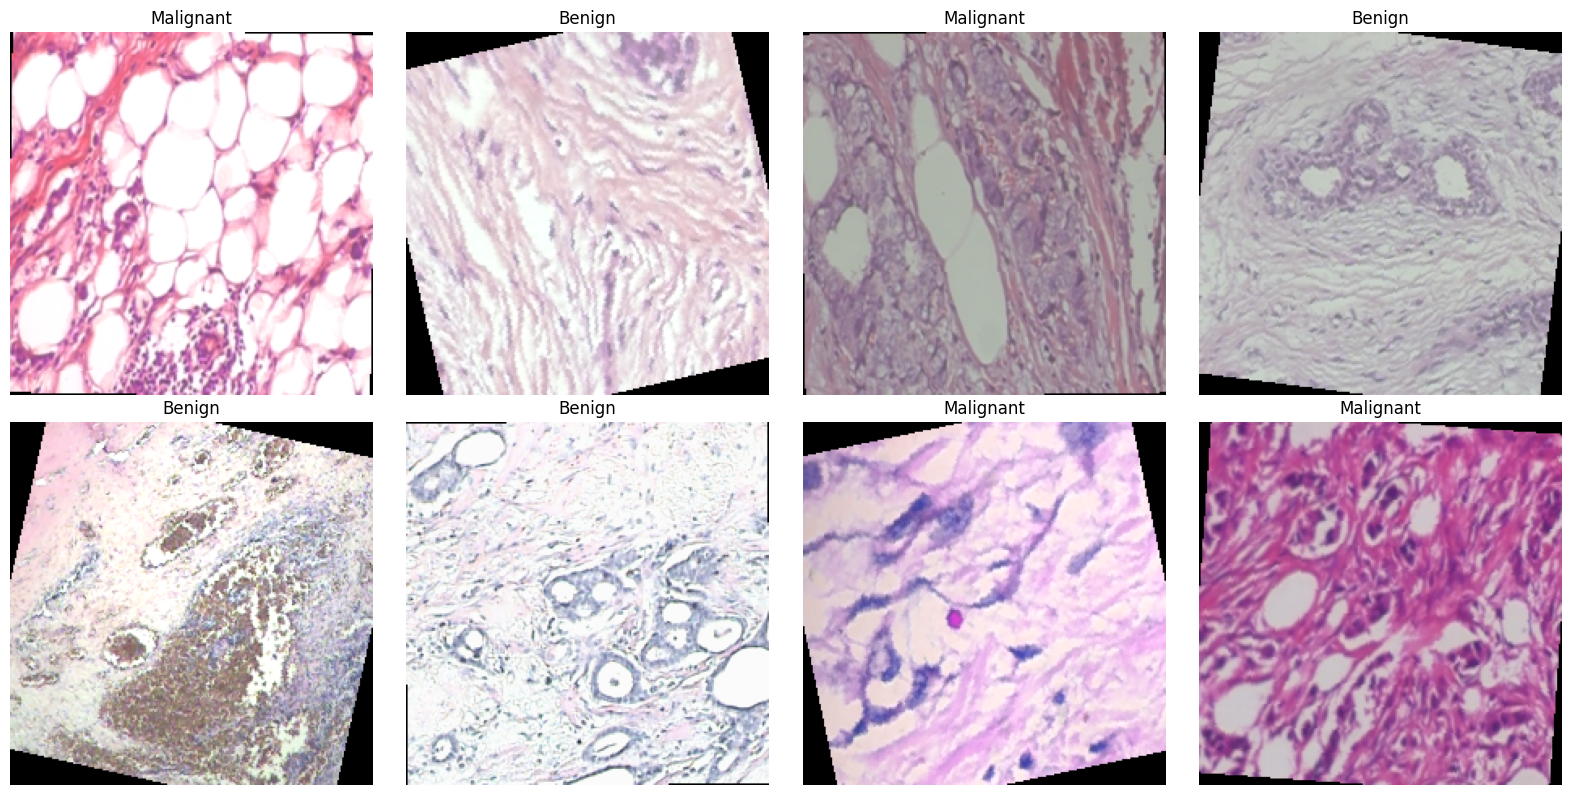

In [19]:
import matplotlib.pyplot as plt
import torch

def show_random_images(dataloader, class_names=None, n_images=8):

    images, labels = next(iter(dataloader))

    indices = torch.randperm(len(images))[:n_images]

    images = images[indices]
    labels = labels[indices]

    # Undo ImageNet normalization
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    images = images * std + mean
    images = images.clamp(0, 1)

    cols = 4
    rows = (n_images + cols - 1) // cols

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i in range(n_images):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(images[i].permute(1, 2, 0))

        if class_names:
            plt.title(class_names[labels[i].item()])
        else:
            plt.title(f"Label: {labels[i].item()}")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

manual_seed = 42
show_random_images(
    train_loader,
    class_names=["Benign", "Malignant"]
)

In [22]:
weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]


In [23]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [24]:
model.fc = nn.Sequential(
            nn.Linear(model.fc.in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 2)
        )

In [25]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

In [27]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].values
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)


optimizer = torch.optim.Adam(model.parameters(), lr=3e-5, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",      # because we're monitoring F1
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

In [28]:
from tqdm import tqdm
import torch

def train_one_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    running_loss = 0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    for images, labels in tqdm(dataloader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

        correct += (preds == labels).sum().item()

        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1

In [29]:
def validate(model, dataloader, criterion, device):

    model.eval()

    running_loss = 0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():

        for images, labels in tqdm(dataloader):

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            correct += (preds == labels).sum().item()

            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    epoch_f1 = f1_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, epoch_f1

In [30]:
manual_seed = 42
train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []


NUM_EPOCHS = 30

best_f1 = 0

# warmup phase
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

for epoch in range(NUM_EPOCHS):
    if epoch == 4:
        for param in model.parameters():
            param.requires_grad = True
        for param in model.fc.parameters():
            param.requires_grad = True

    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc, val_f1 = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "best_model.pth")

    scheduler.step(val_f1)

    print(
        f"Epoch {epoch+1}/{NUM_EPOCHS}"
        f" | Train Loss: {train_loss:.4f}"
        f" | Train Acc: {train_acc:.4f}"
        f" | Val Loss: {val_loss:.4f}"
        f" | Val Acc: {val_acc:.4f}"
        f" | Val F1: {val_f1:.4f}"
    )

100%|██████████| 28/28 [00:07<00:00,  3.59it/s]


Epoch 1/30 | Train Loss: 0.6175 | Train Acc: 0.6445 | Val Loss: 0.5303 | Val Acc: 0.7753 | Val F1: 0.8167


100%|██████████| 28/28 [00:06<00:00,  4.29it/s]


Epoch 2/30 | Train Loss: 0.5233 | Train Acc: 0.7394 | Val Loss: 0.5014 | Val Acc: 0.8036 | Val F1: 0.8397


100%|██████████| 28/28 [00:06<00:00,  4.36it/s]


...

Epoch 28/30 | Train Loss: 0.0666 | Train Acc: 0.9821 | Val Loss: 0.1668 | Val Acc: 0.9353 | Val F1: 0.9500


100%|██████████| 28/28 [00:06<00:00,  4.36it/s]


Epoch 29/30 | Train Loss: 0.0691 | Train Acc: 0.9795 | Val Loss: 0.1774 | Val Acc: 0.9251 | Val F1: 0.9406


100%|██████████| 28/28 [00:06<00:00,  4.32it/s]

Epoch 30/30 | Train Loss: 0.0672 | Train Acc: 0.9788 | Val Loss: 0.1670 | Val Acc: 0.9319 | Val F1: 0.9478


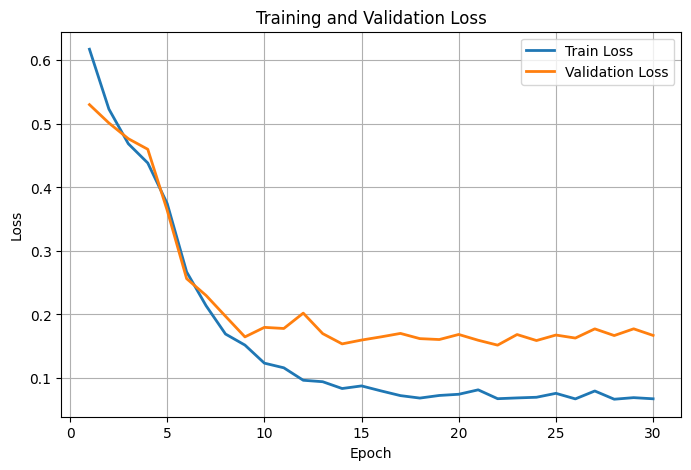

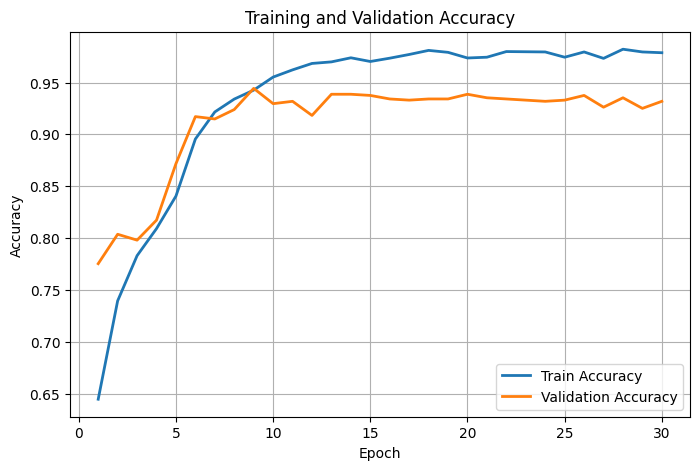

In [31]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Loss
plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Train Loss", linewidth=2)
plt.plot(epochs, val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(epochs, train_accuracies, label="Train Accuracy", linewidth=2)
plt.plot(epochs, val_accuracies, label="Validation Accuracy", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [32]:

def evaluate(model, dataloader, device):
    manual_seed = 42
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:, 1]

            preds = outputs.argmax(dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds)
    recall = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)

    cm = confusion_matrix(all_labels, all_preds)

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC AUC  : {auc:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(classification_report(all_labels, all_preds))

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm
    }

Accuracy : 0.8447
Precision: 0.8261
Recall   : 0.9360
F1 Score : 0.8776
ROC AUC  : 0.9315

Confusion Matrix
[[491 200]
 [ 65 950]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.71      0.79       691
           1       0.83      0.94      0.88      1015

    accuracy                           0.84      1706
   macro avg       0.85      0.82      0.83      1706
weighted avg       0.85      0.84      0.84      1706



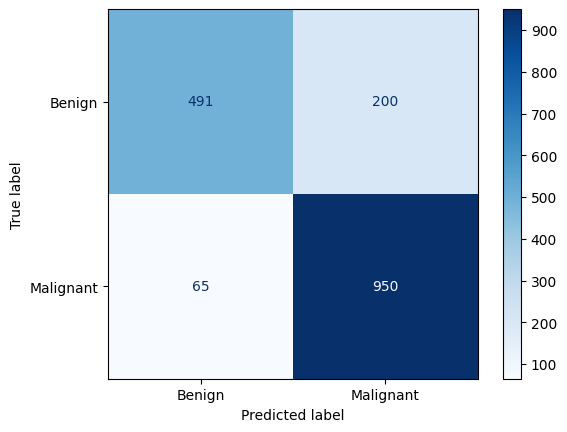

In [33]:
model.load_state_dict(torch.load("best_model.pth"))

metrics = evaluate(
    model,
    test_loader,
    device
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=metrics["confusion_matrix"],
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")
plt.show()